# Домашнє завдання: Статистичні візуалізації з Seaborn

## Опис завдання
У цьому домашньому завданні ви будете використовувати бібліотеку Seaborn для створення красивих статистичних візуалізацій. Seaborn має кращий стандартний стиль та спеціалізується на статистичних графіках.

**Опис колонок:**
- `datetime` - дата та час
- `season` - квартал (1-Q1, 2-Q2, 3-Q3, 4-Q4)
- `holiday` - чи є день святковим (0=ні, 1=так)
- `workingday` - чи є день робочим (0=ні, 1=так)
- `weather` - погодні умови (1=ясно, 2=туман, 3=легкий дощ, 4=сильний дощ)
- `temp` - температура в градусах Цельсія
- `atemp` - як відчувається температура
- `humidity` - вологість (%)
- `windspeed` - швидкість вітру
- `casual` - кількість випадкових користувачів
- `registered` - кількість зареєстрованих користувачів
- `count` - загальна кількість орендованих велосипедів

## Підготовка даних

---
🌱 Коментар щодо сезонності

Колонка season у датасеті представляє саме квартали року, а не метеорологічні сезони. Тому всі аналізи сезонності ви можете будувати на основі кварталів.

Водночас дані були зібрані в Індії, де поділ на сезони інший, ніж у Європі чи США. Якщо ви хочете дослідити сезонність відповідно до індійської системи сезонів, можна створити окрему колонку.

Справжні сезони в Індії:

| Сезон        | Місяці                     |
| ------------ | -------------------------- |
| Winter       | December–February (12,1,2) |
| Summer       | March–May (3,4,5)          |
| Monsoon      | June–September (6,7,8,9)   |
| Post-monsoon | October–November (10,11)   |


Тоді потрібно зробити нову колонку weather_season_india, мапнувши місяці так:

12, 1, 2 → 1 (Winter)

3, 4, 5 → 2 (Summer)

6–9 → 3 (Monsoon)

10–11 → 4 (Post-Monsoon)

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Завантаження даних
df = pd.read_csv('/content/drive/MyDrive/Data/yulu_rental.csv')
df['datetime'] = pd.to_datetime(df['datetime'])
df.set_index('datetime', inplace=True)

# Встановлюємо стиль seaborn
sns.set_theme(style="whitegrid")

# Додамо додаткові колонки для аналізу
df['date'] = df.index.date
df['day'] = df.index.day
df['week'] = df.index.isocalendar().week
df['weekday_num'] = df.index.weekday
df['weekday'] = df.index.day_name()
df['year'] = df.index.year
df['month'] = df.index.month
df['hour'] = df.index.hour

In [4]:
df.head()

,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count,date,day,week,weekday_num,weekday,year,month,hour
datetime,,,,,,,,,,,,,,,,,,,
2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,16,2011-01-01,1,52,5,Saturday,2011,1,0
2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,32,40,2011-01-01,1,52,5,Saturday,2011,1,1
2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0,5,27,32,2011-01-01,1,52,5,Saturday,2011,1,2
2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0,3,10,13,2011-01-01,1,52,5,Saturday,2011,1,3
2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0,0,1,1,2011-01-01,1,52,5,Saturday,2011,1,4



---

## Завдання 1: Лінійний графік з довірчими інтервалами

**Завдання:**
Побудуйте лінійний графік середньої кількості оренд помісячно з довірчими інтервалами (confidence intervals) рівними 1 стандартному відхиленню.

**УВАГА!** В лекції ми будували подібний графік, але там були дані по номеру місяця, а тут треба зобразити дані в розрізі місяць_рік.

В якості підказки вам наведений код для створення колонки, яка містить `місяць_рік`. Як її використати - вже питання до вас :)

Очікуваний результат:
![](https://drive.google.com/uc?id=1uVKqfY1VlhVMaM3wu99uVGT1f7S0Vf8S)

**Питання для інтерпретації:**
- В які місяці найбільша невизначеність в даних?

In [5]:
df['month_year'] = df.index.to_period('M')
df['month_year']  = df.month_year.astype(str)

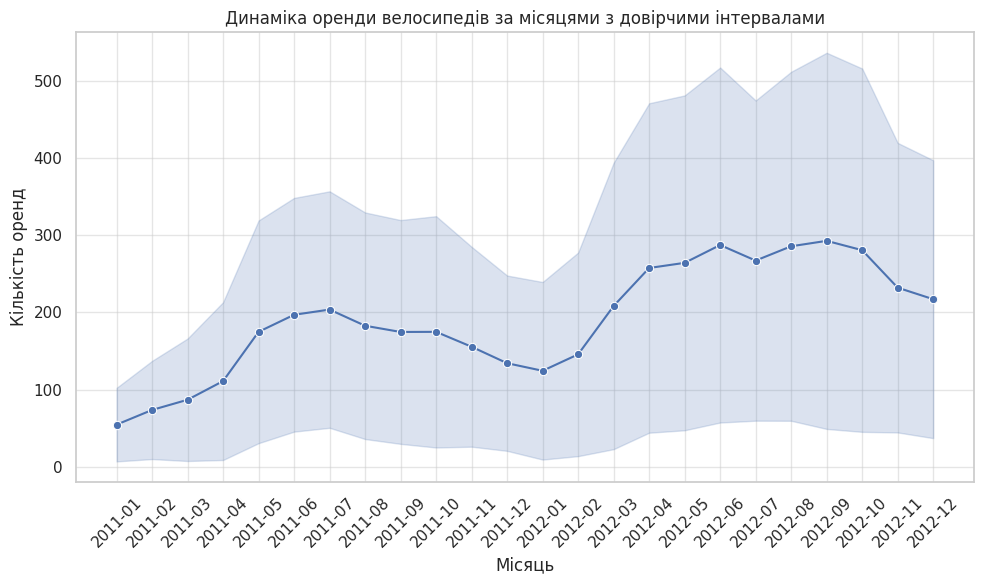

In [16]:
sns.set_theme(style="whitegrid")

plt.figure(figsize=(10, 6))

sns.lineplot(data=df, x='month_year', y='count', errorbar='sd', marker='o')

plt.title('Динаміка оренди велосипедів за місяцями з довірчими інтервалами')
plt.xlabel('Місяць')
plt.ylabel('Кількість оренд')

plt.grid(alpha=0.5)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Найбільша невизначеність спостерігається в теплі місяці (переважно травень–вересень), оскільки саме в цей період довірчі інтервали є найширшими через певні причини: погода, свята, тощо.

## Завдання 2: Порівняння стилів - Pandas vs Seaborn гістограма

**Завдання:**
Побудуйте гістограму розподілу температури двома способами - з Pandas та Seaborn - та порівняйте візуальний вигляд. Задайте однакову кількість бінів в цих візуалізаціях, відмінну від стандартної. В візуалізації Seaborn додайте параметр при побудові `kde=True`.

**Функція Seaborn: `sns.histplot()`**

Можна побудувати окремо два графіки. Але для тих, хто хоче складніше - побудуйте ці 2 графіки на 1 фігурі.

**Дайте відповідь на питання:**
1. Яка візуальна різниця між Pandas та Seaborn гістограмами?
2. Що за лінія додаткова на графіку в Seaborn? Як вона називається і як ви б її описали своїми словами?

**Спосіб №1 (Pandas)**

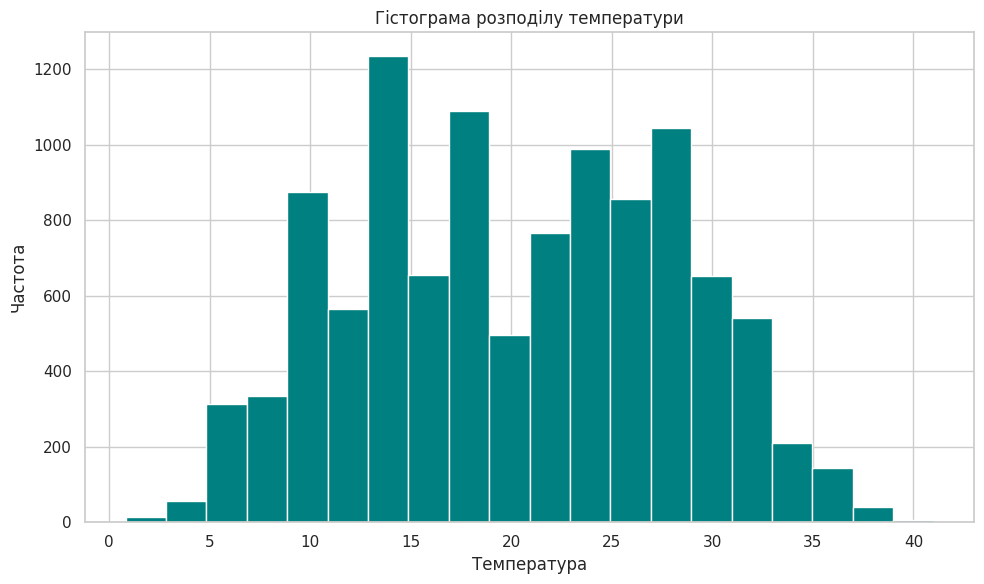

In [27]:
df['temp'].plot.hist(
    figsize=(10, 6),
    bins=20,
    color='teal',
    title='Гістограма розподілу температури',
    xlabel='Температура',
    ylabel='Частота'
)

plt.tight_layout()

**Спосіб №2 (Seaborn)**

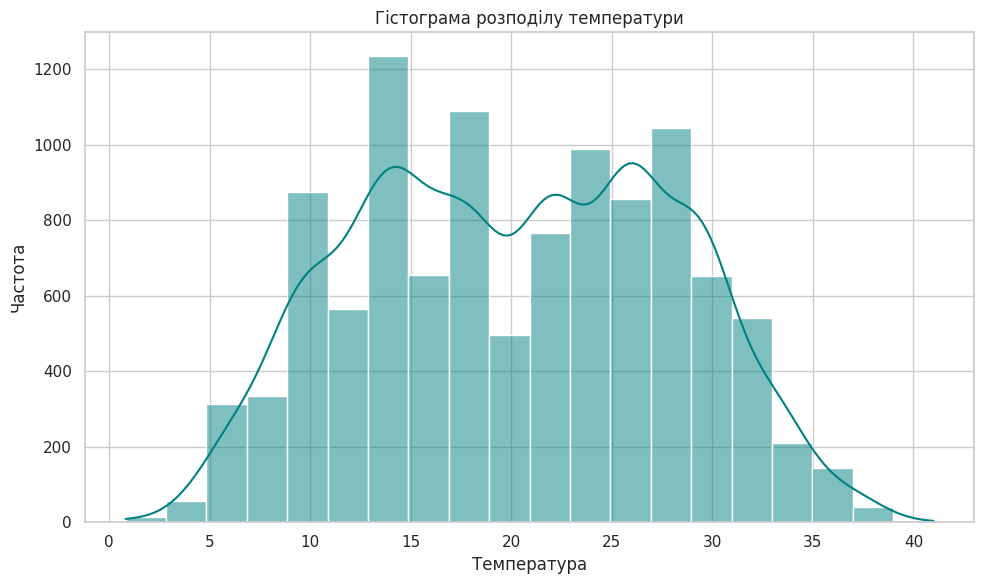

In [33]:
plt.figure(figsize=(10, 6))

sns.histplot(data=df, x='temp', bins=20, kde=True, color='teal')

plt.title('Гістограма розподілу температури')
plt.xlabel('Температура')
plt.ylabel('Частота')
plt.tight_layout()
plt.show()

1. **Яка візуальна різниця між Pandas та Seaborn гістограмами?**

Графіки відрізняються інтенсивністю коліру, хоч я і задала однаковий без додаткових параметрів.

2. **Що за лінія додаткова на графіку в Seaborn? Як вона називається і як ви б її описали своїми словами?**

Це крива, яка показує щільність розподілу і допомагає зрозуміти, де значення трапляються найчастіше. Вона може допомогти визначити тип розподілу, скільки піків трапляється.

## Завдання 3: Box Plot порівняння - Pandas vs Seaborn

**Завдання:**
Побудуйте box plot для кількості погодинних оренд велосипедів за погодними умовами з Pandas та Seaborn.

**Функція Seaborn: `sns.boxplot()`**

Можна побудувати окремо два графіки. Але для тих, хто хоче складніше - побудуйте ці 2 графіки на 1 фігурі.

Просунуте доповнення:
- підпишіть погодні умови їх інтерпретацією з опису даних в обох графіках

**Дайте відповідь на питання:**
- Яка візуальна різниця між Pandas та Seaborn бокс-плотами?

In [34]:
weather_labels = {
    1: 'Ясно',
    2: 'Туман',
    3: 'Легкий дощ',
    4: 'Сильний дощ'
}

df['weather_name'] = df['weather'].map(weather_labels)

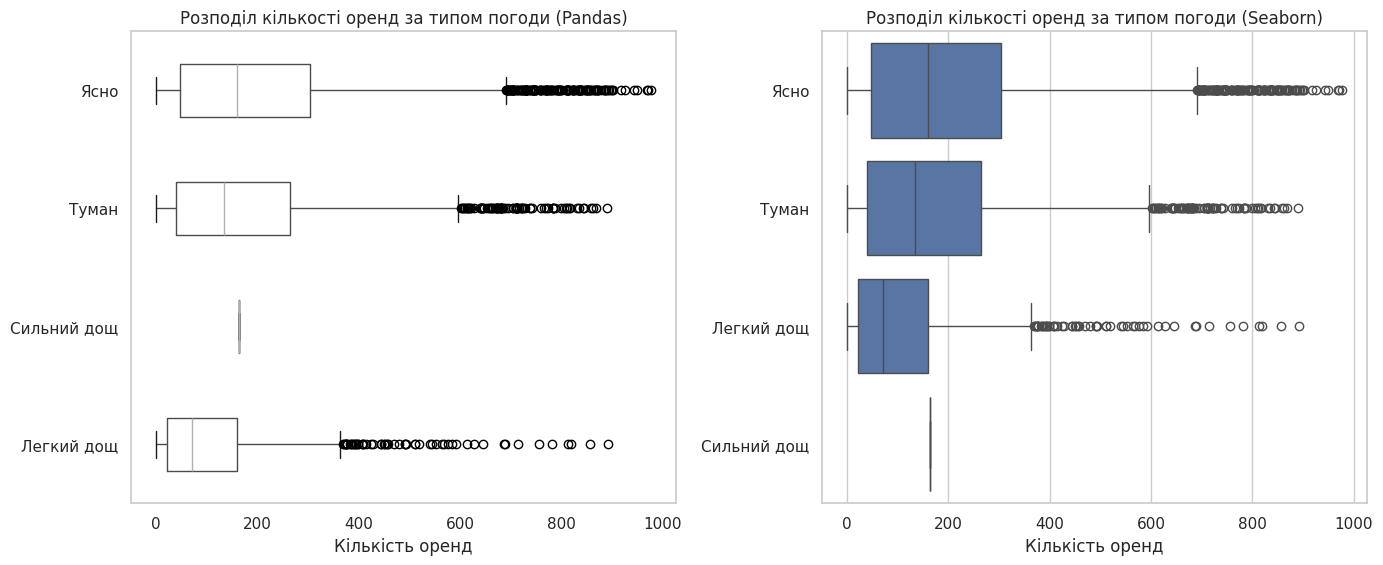

In [42]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Візуалізація з Pandas

df.boxplot(
    column='count',
    by='weather_name',
    grid = False,
    vert = False,
    ax=axes[0]
)
axes[0].set_title('Розподіл кількості оренд за типом погоди (Pandas)')
axes[0].set_xlabel('Кількість оренд')
axes[0].set_ylabel('')

plt.suptitle('')

# Візуалізація з Seaborn

sns.boxplot(data=df, x='count', y='weather_name', ax=axes[1])

axes[1].set_title('Розподіл кількості оренд за типом погоди (Seaborn)')
axes[1].set_xlabel('Кількість оренд')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

**Яка візуальна різниця між Pandas та Seaborn бокс-плотами?**

Не задаючі додаткові параметри можна сказати, що:

*   В Seaborn ящик автоматично заповнюється кольором
*   В Seaborn ящики більші розміром за висотою



<!-- - -->
## Завдання 4: Heatmap кореляційної матриці

**Завдання:**
Створіть із Seaborn кореляційну матрицю з забарвленням heatmap (колір відповідає величині значення в клітинці) числових змінних в наших даних з анотаціями значень.

**Дайте відповіді на питання по графіку:**
1. Які змінні найсильніше корелюють з загальною кількістю оренди (count)?
2. Яка кореляція між temp та atemp? Чому?
3. Які змінні мають негативну кореляцію?


In [46]:
# Для даного завдання обираємо лише колонки, що мають числові значення

numeric_df = df.select_dtypes(include='number')
correlation = numeric_df.corr()

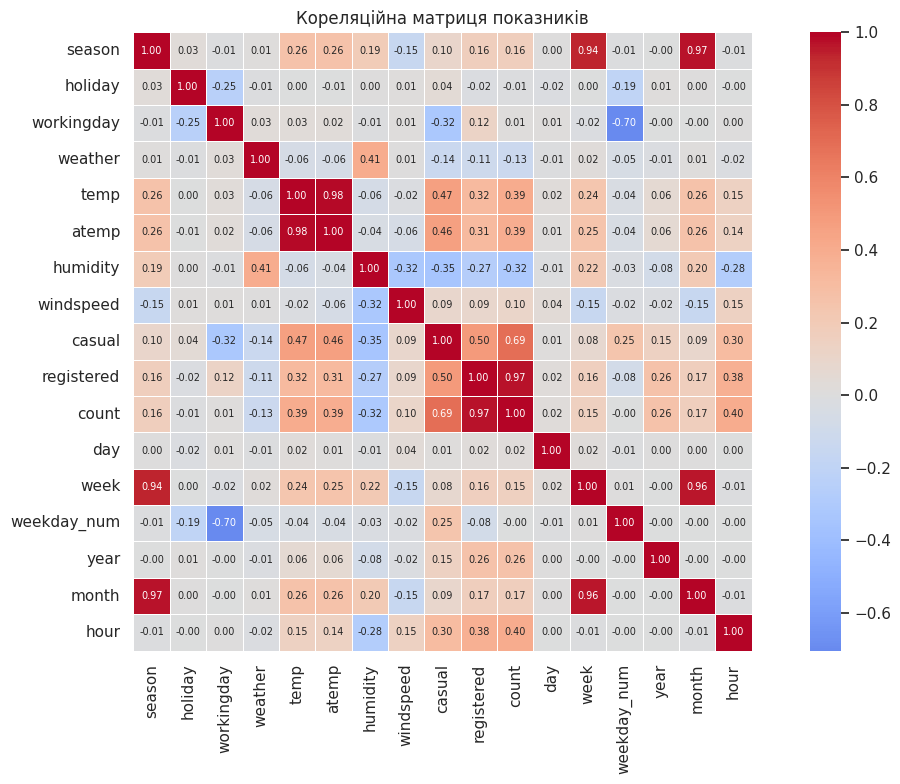

In [55]:
plt.figure(figsize=(12,8))

sns.heatmap(correlation, annot=True, cmap='coolwarm', center=0,
            square=True, fmt='.2f', linewidths=0.5, annot_kws={"size": 7})

plt.title('Кореляційна матриця показників')
plt.tight_layout()
plt.show()

1. **Які змінні найсильніше корелюють з загальною кількістю оренди (count)?**

Змінні **registered (0.97)** та **casual (0.69)** найчастіше корелюють зі змінною count

2. **Яка кореляція між temp та atemp? Чому?**

Значення кореляції між цими змінними складає 0.98, тобто кореляція дуже висока, але не 1. Це повʼязано з тим, що те, на як відчувається температура впливаються додаткові фактори: вологість, вітер, і т.д.

3. **Які змінні мають негативну кореляцію?**

humidity ↔ count (-0.32)
humidity ↔ casual (-0.35)
windspeed ↔ humidity (-0.32)
workingday ↔ casual (-0.32)
weekday_num ↔ workingday (-0.70)

Значення humidity найчастіше має негативні кореляції з іншими показниками. Тому можна зробити висновок, що вологість впливає на оренду велосипедів.

## Завдання 5: Violin Plot для глибокого аналізу розподілів

**Завдання:**
Створіть violin plot для аналізу розподілу оренди за кварталами.

Дайте відповіді на питання:

**Питання для інтерпретації:**
1. Що показує "товщина" violin plot?
2. В якому кварталі найбільша варіабельність оренди?
3. Яка перевага violin plot над звичайним box plot?


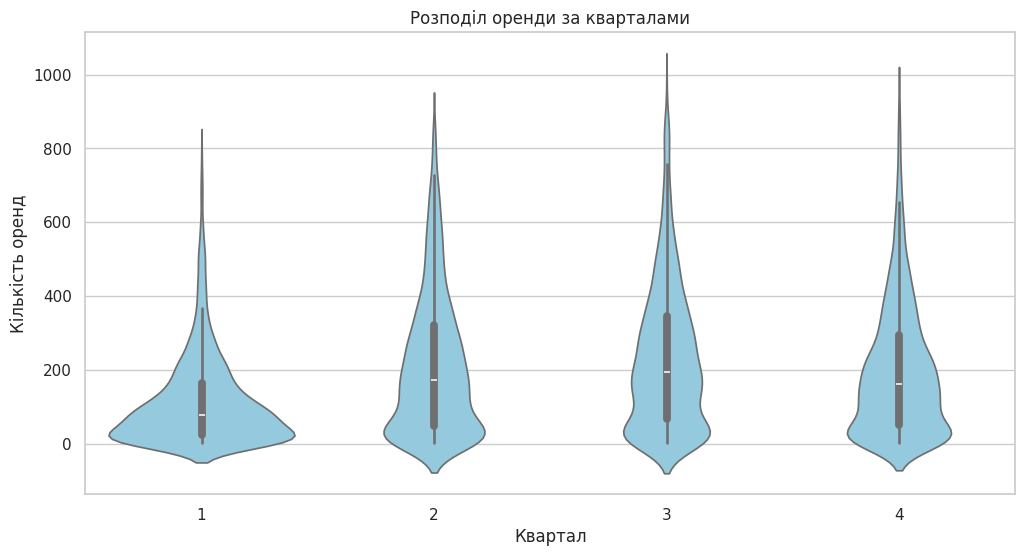

In [59]:
plt.figure(figsize=(12,6))

sns.violinplot(data=df, x='season', y='count', color='skyblue')

plt.title('Розподіл оренди за кварталами')
plt.xlabel('Квартал')
plt.ylabel('Кількість оренд')
plt.tight_layout
plt.show()

## Завдання 6 : Pairplot для мультиваріативного аналізу

**Завдання:**
Створіть pairplot для аналізу взаємозв'язків між ключовими змінними `'temp', 'humidity', 'windspeed', 'count'` . В якості візуальної розбивки за категоріями (параметр `hue`) додайте season (квартал).

Дайте відповіді на питання:

**Питання для інтерпретації:**
1. Між якими змінними спостерігається найсильніший лінійний зв'язок?
2. Яка характеристика найбільше відрізняється між кварталами?

<Figure size 1200x800 with 0 Axes>

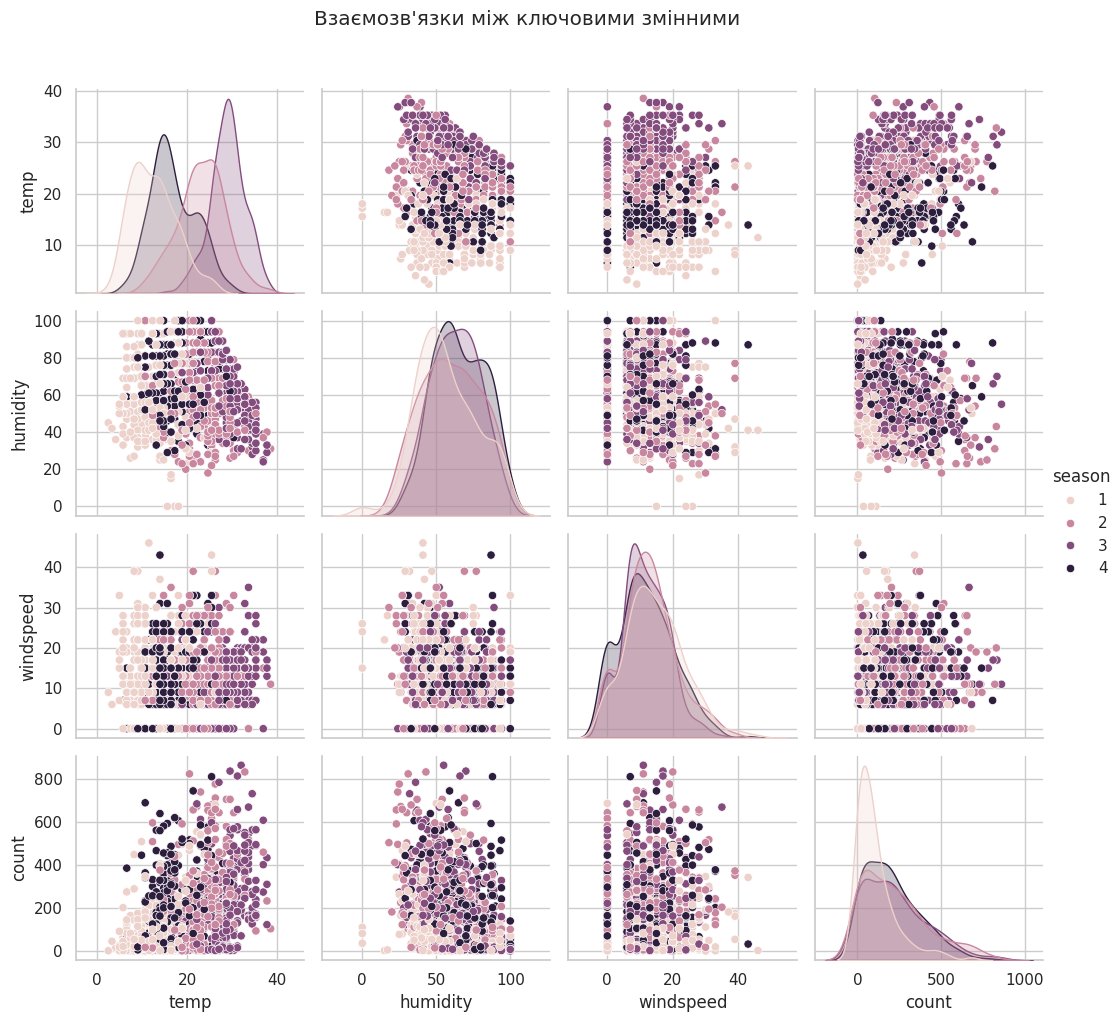

In [78]:
df_sample = df.sample(frac=0.1)

plt.figure(figsize=(12, 8))

g = sns.pairplot(df_sample, height=2.5,
             vars=['temp', 'humidity', 'windspeed', 'count'],
             hue='season')

g._legend.set_bbox_to_anchor((1.05, 0.5))
plt.suptitle('Взаємозв\'язки між ключовими змінними', y=1.02)
plt.tight_layout()
plt.show()


1. **Між якими змінними спостерігається найсильніший лінійний зв'язок?**

Найсильніший лінійний зв\язок спостерігається між змінними temp та count. Чим вища температура, тим більша кількість оренд.

2. **Яка характеристика найбільше відрізняється між кварталами?**

Найбільша відмінність між кварталами спостерігається для температури (temp), є чітке розділення по кольорах, оскільки вона суттєво змінюється залежно від сезону.

## Завдання 7: Joint Plot для детального аналізу двох змінних

**Завдання:**
Проаналізуйте залежність між температурою та орендою за допомогою joint plot. В якості візуальної розбивки за категоріями (параметр `hue`) додайте `workingday`.

Дайте відповіді на питання:

**Питання для інтерпретації:**
1. Що показують графіки по краях?
2. Чи є різниця у поведінці користувачів у робочий і неробочий день?

In [88]:
df_sample['workingday_name'] = df_sample['workingday'].map({
    0: 'Вихідний',
    1: 'Робочий'
})

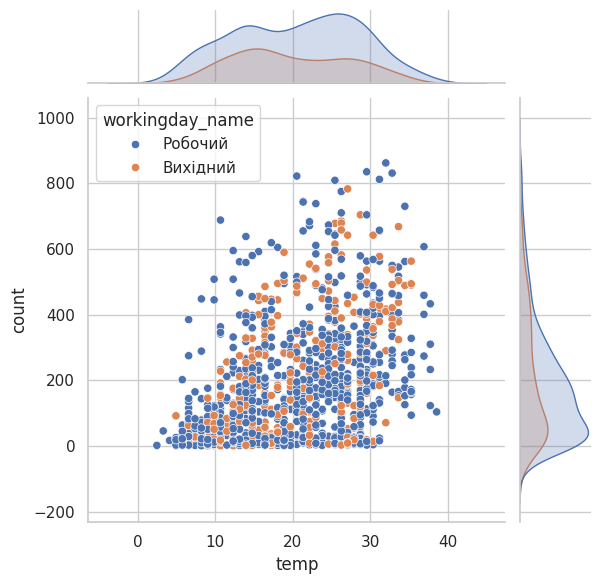

In [90]:
sns.jointplot(data=df_sample, x='temp', y='count', hue='workingday_name')

1. **Що показують графіки по краях?**

Це графіки, які показують, як розподіляються значення температури та кількості оренд для різних типів днів.

2. **Чи є різниця у поведінці користувачів у робочий і неробочий день?**

Між робочими та вихідними днями є незначна різниця: у робочі дні кількість оренд трохи вища, що може бути повʼязано з тим, що велосипеди орендують для поїздок на роботу. Але загалом розподіли значною мірою перекриваються.